# AI-XRay · 02 — Preprocesamiento y Data Augmentation

**Clase 4 · Laboratorio Práctico Dirigido — Proyecto Final Independiente**

### Objetivo de este notebook
1. Cargar el manifiesto con split (`data/processed/manifest_split.csv`) generado en `01_exploracion.ipynb`.
2. Construir los `tf.data.Dataset` de train/val/test con `src/preprocessing.py`.
3. Verificar visualmente el resize a 224×224, el `preprocess_input` de ResNet50 y la data augmentation.
4. Confirmar que los tamaños de batch y las formas de los tensores son las que espera el modelo.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import BATCH_SIZE, IMG_SIZE, SPLIT_MANIFEST_PATH
from src.preprocessing import dataset_from_manifest

split = pd.read_csv(SPLIT_MANIFEST_PATH)
split["label_name"] = split["label"].map({0: "NORMAL", 1: "PNEUMONIA"})
split.groupby(["split", "label_name"]).size()


split  label_name
test   NORMAL        150
       PNEUMONIA     147
train  NORMAL        700
       PNEUMONIA     702
val    NORMAL        150
       PNEUMONIA     151
dtype: int64

## 1. Construir los datasets de train/val/test

In [2]:
train_ds = dataset_from_manifest(split, "train", batch_size=BATCH_SIZE)
val_ds = dataset_from_manifest(split, "val", batch_size=BATCH_SIZE)
test_ds = dataset_from_manifest(split, "test", batch_size=BATCH_SIZE)

for x, y in train_ds.take(1):
    print("Batch de train -- shape:", x.shape, "dtype:", x.dtype)
    print("Labels de ejemplo:", y.numpy()[:8])
    print("Rango de valores (tras preprocess_input, ya NO está en [0,1]):", float(x.numpy().min()), "a", float(x.numpy().max()))


Batch de train -- shape: (32, 224, 224, 3) dtype: <dtype: 'float32'>
Labels de ejemplo: [1. 1. 0. 1. 0. 1. 1. 1.]
Rango de valores (tras preprocess_input, ya NO está en [0,1]): -123.68000030517578 a 151.06100463867188


## 2. Por qué `preprocess_input` y no una normalización 0-1

`tf.keras.applications.resnet50.preprocess_input` resta el promedio de canal (BGR) calculado
sobre ImageNet -- **no** produce valores en [0, 1]. Usar `img / 255.0` en su lugar es un error
común: el modelo preentrenado seguiría funcionando, pero con una distribución de entrada
distinta a la que aprendió durante el preentrenamiento, degradando el beneficio del transfer
learning. La celda anterior ya lo muestra: el rango de valores no es [0, 1].

## 3. Verificación visual del pipeline (antes de entrenar nada)

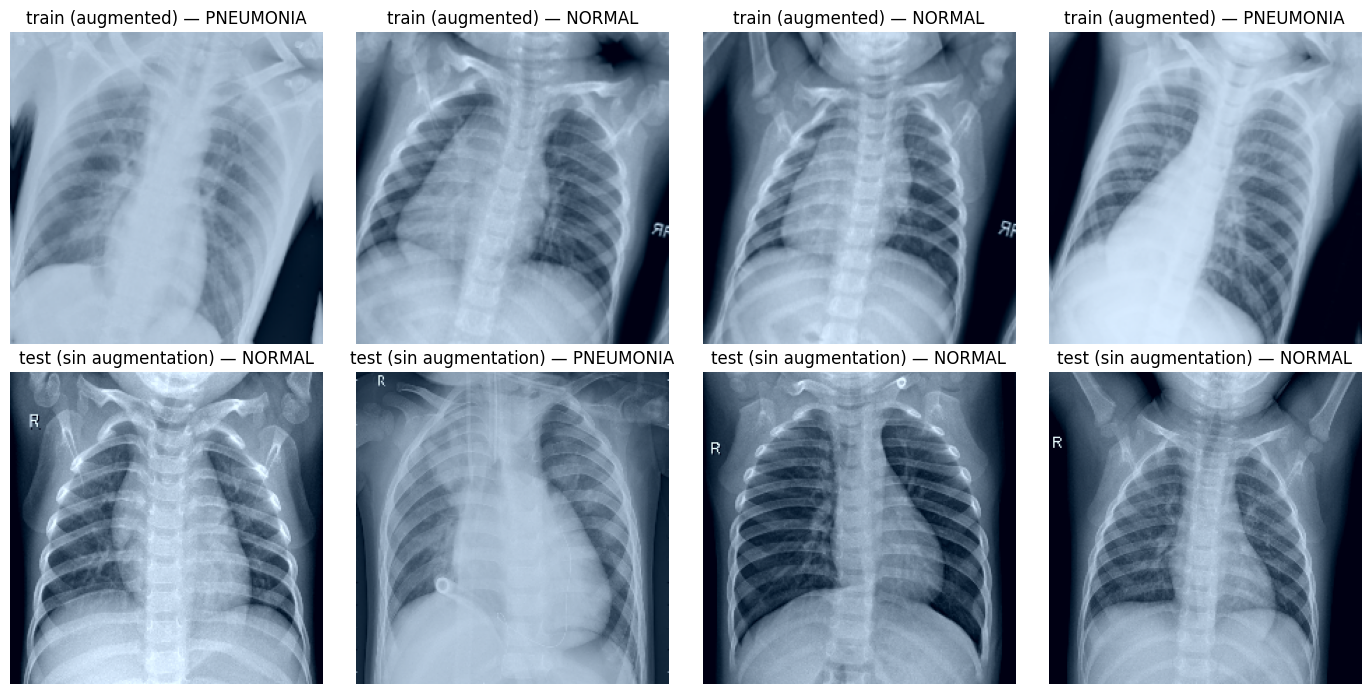

In [3]:
def _denormalize_for_display(img):
    # Solo para visualizar: revierte aproximadamente el preprocess_input de ResNet50
    # (que resta medias BGR de ImageNet) para que la imagen se vea reconocible.
    mean = np.array([103.939, 116.779, 123.68])
    img = img[..., ::-1] + mean  # BGR -> RGB, suma de medias
    return np.clip(img, 0, 255).astype("uint8")

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for (x, y), ax_row_idx in zip([next(iter(train_ds))], [0]):
    for i in range(4):
        axes[0][i].imshow(_denormalize_for_display(x.numpy()[i]))
        label = "PNEUMONIA" if y.numpy()[i] == 1 else "NORMAL"
        axes[0][i].set_title(f"train (augmented) — {label}")
        axes[0][i].axis("off")

for (x, y) in test_ds.take(1):
    for i in range(4):
        axes[1][i].imshow(_denormalize_for_display(x.numpy()[i]))
        label = "PNEUMONIA" if y.numpy()[i] == 1 else "NORMAL"
        axes[1][i].set_title(f"test (sin augmentation) — {label}")
        axes[1][i].axis("off")

plt.tight_layout()
plt.show()


**Qué observar:** las imágenes de `train` (fila de arriba) deben verse con variaciones
sutiles de flip/rotación/zoom/contraste entre corridas; las de `test` (fila de abajo) deben
verse siempre igual (sin augmentation) -- así se evalúa el modelo en condiciones
consistentes, no artificialmente "ayudado" por variaciones aleatorias.

### Cierre
Con los pipelines de datos verificados, continúa en `03_training.ipynb` para entrenar y
comparar las variantes del modelo.